# Suffix vs Non-suffix Words

### Packages

In [29]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split

from data_processing import DataGenerator, correct_nasal_vowel_transcripts
from model import GenderLSTM
from model_evaluation import baseline_accuracy, compare_accuracies, statistical_check, plot_metrics

### Hyperparameters

In [30]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
hyperparameters = {
    'embed_dim': 128,
    'hidden_size': 256,
    'batch_size': 64,
    'n_epochs': 20,
    'lr': 0.001
}

### Data Preparation

In [31]:
# Flexique data preprocessing

nlexique = pd.read_csv('data/nlexique.csv')
nlexique = nlexique[['lexeme', 'sg', 'gen']].rename(columns={'sg': 'phon'}).dropna().reset_index(drop=True)
tilde = nlexique.iloc[-1]['phon'][-1]
nlexique['phon'] = nlexique['phon'].apply(correct_nasal_vowel_transcripts)
nlexique

,lexeme,phon,gen
0,à-côté,akOte,m
1,à-coup,aku,m
2,à-peu-près,apØpʁɛ,m
3,à-pic,apik,m
4,à-plat,apla,m
...,...,...,...
30999,zurichois,zyʁikwa,m
31000,zydeco,zidəko,f
31001,zygoma,zigOma,m
31002,zygote,zigɔt,m


In [32]:
# Echantinom data preprocessing

echantinom = pd.read_csv('data/Echantinom-full-20210902.csv')
echantinom.loc[
    echantinom['lemma'].isin(nlexique.query("gen == 'b'").lexeme),
    'gen'
] = 'b'
echantinom = echantinom[echantinom['gen'] != 'b'][['lemma', 'gen', 'phon', 'suffix']].reset_index(drop=True)
echantinom = pd.merge(echantinom, nlexique, left_on='lemma', right_on='lexeme', how='left', suffixes=('_y', ''))\
           .drop(columns=['lexeme', 'phon_y', 'gen_y']).dropna().reset_index(drop=True)
echantinom

,lemma,suffix,phon,gen
0,berlingue,0,bɛʁl3g,m
1,corton,on,kɔʁt2,m
2,dabuche,uche,dabyʃ,f
3,faf,0,faf,m
4,gail,0,gaj,f
...,...,...,...,...
4527,palu,0,paly,m
4528,talc,0,talk,m
4529,sauvetage,age,sOvətaʒ,m
4530,plaid,0,plɛd,m


In [33]:
# Orthographic Forms

orth_train = nlexique[(~nlexique['lexeme'].isin(echantinom['lemma'])) & (nlexique['gen'] != 'b')][['lexeme', 'gen']]
orth_train.to_csv('data/orth_train+valid.csv', index=None)

orth_test = echantinom[['lemma', 'gen']]
orth_test.to_csv('data/orth_test.csv', index=None)

In [34]:
# Phonemic Forms

phon_train = nlexique[(~nlexique['lexeme'].isin(echantinom['lemma'])) & (nlexique['gen'] != 'b')][['phon', 'gen']]
phon_train.to_csv('data/phon_train+valid.csv', index=None)

phon_test = echantinom[['phon', 'gen']]
phon_test.to_csv('data/phon_test.csv', index=None)

---
## ☑️ Orthographic forms (reversed) 

In [35]:
orth_train_valid = pd.read_csv('data/orth_train+valid.csv')
orth_test = pd.read_csv('data/orth_test.csv')
orth_train, orth_valid = train_test_split(orth_train_valid, test_size=0.2, random_state=42)

print("Dataset Sizes:")
print(f"Train: {len(orth_train)}")
print(f"Valid: {len(orth_valid)}")
print(f"Test: {len(orth_test)}")

Dataset Sizes:
Train: 19904
Valid: 4976
Test: 4532


In [ ]:
orth_train_generator_backward = DataGenerator(orth_train, reverse_nouns=True)
orth_valid_generator_backward = DataGenerator(orth_valid, parentgenerator=orth_train_generator_backward, reverse_nouns=True)

orth_model_backward = GenderLSTM(
    datagenerator=orth_train_generator_backward, 
    embedding_dim=hyperparameters['embed_dim'], 
    hidden_dim=hyperparameters['hidden_size'], 
    device=DEVICE, 
    reversed=True
    )

orth_backward_train_metrics, orth_backward_valid_metrics = orth_model_backward.train_model(
    traingenerator=orth_train_generator_backward,
    validgenerator=orth_valid_generator_backward,
    n_epochs=hyperparameters['n_epochs'],
    batch_size=hyperparameters['batch_size'],
    learning_rate=hyperparameters['lr'],
    verbose=True,
    save_model='models/orth_backward.pth'
    )

Epoch: 0
[Train] Loss: 0.3768   Accuracy: 84.91%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 59.68%
[Valid] Loss: 0.4038   Accuracy: 81.94%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 65.63%
----------------------------------------------------------------------------------------------------
Epoch: 1
[Train] Loss: 0.2646   Accuracy: 89.64%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 62.46%
[Valid] Loss: 0.2776   Accuracy: 87.51%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 63.44%
----------------------------------------------------------------------------------------------------
Epoch: 2
[Train] Loss: 0.2298   Accuracy: 90.74%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 63.03%
[Valid] Loss: 0.2724   Accuracy: 88.38%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 64.31%
---------------------------------------------

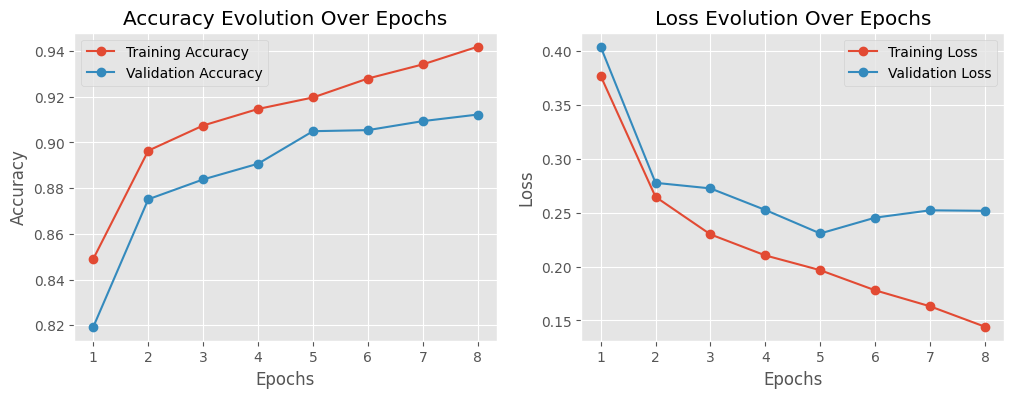

In [37]:
# Accuracy and Loss evolution throughout training

orth_backward_accuracies = {
    'Training Accuracy': orth_backward_train_metrics['accuracy'],
    'Validation Accuracy': orth_backward_valid_metrics['accuracy']
}

orth_backward_losses = {
    'Training Loss': orth_backward_train_metrics['loss'],
    'Validation Loss': orth_backward_valid_metrics['loss']
}

plot_metrics(orth_backward_accuracies, orth_backward_losses)

The most frequent label in the dataset is: m


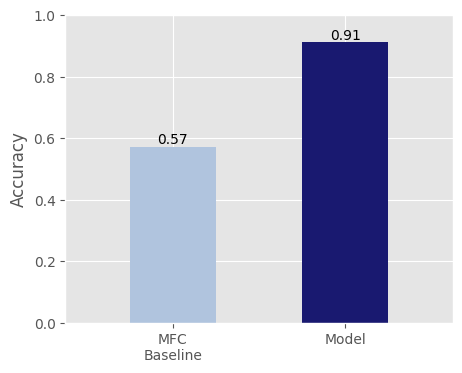

In [38]:
# Comparison with baseline on validation set

baseline_backward_acc = baseline_accuracy(orth_train_generator_backward, orth_valid_generator_backward, verbose=True)

compare_accuracies(baseline_backward_acc, orth_backward_valid_metrics['accuracy'][-1])

In [ ]:
orth_test_generator_backward = DataGenerator(orth_test, parentgenerator=orth_train_generator_backward, reverse_nouns=True)
orth_backward_predictions = orth_model_backward.predict(orth_test_generator_backward, hyperparameters['batch_size'], set='test')

orth_backward_predictions_df = pd.merge(
    pd.DataFrame(orth_backward_predictions), echantinom[['lemma', 'phon']], left_on='Form', right_on='lemma', how='left'
    ).drop('lemma', axis=1)
orth_backward_predictions_df.insert(1, 'Alt Form', orth_backward_predictions_df.pop('phon'))
orth_backward_predictions_df.to_csv('results/orth_backward.csv', index=False)

The most frequent label in the dataset is: m


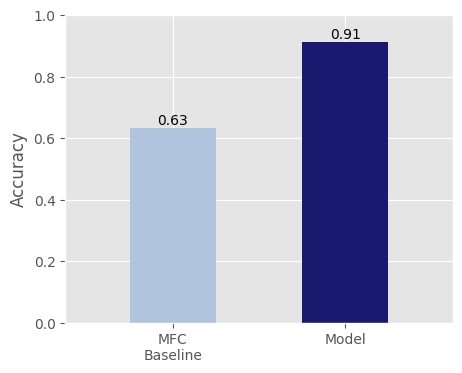

In [40]:
# Comparison with baseline on test set

orth_backward_correct = orth_backward_predictions_df[orth_backward_predictions_df['Predicted Gender'] == orth_backward_predictions_df['True Gender']]
orth_backward_acc = (orth_backward_correct.shape[0] / orth_backward_predictions_df.shape[0])

baseline_backward_acc = baseline_accuracy(orth_train_generator_backward, orth_test_generator_backward, verbose=True)

compare_accuracies(baseline_backward_acc, orth_backward_acc)

In [ ]:
# Averages results over 10 randomly initialized runs

statistical_check(
    orth_train, 
    orth_valid, 
    orth_test, 
    hyperparameters, 
    outfile='results/orth_backward_x10.csv', 
    runs=10, 
    reverse_nouns=True, 
    device=DEVICE
    )

'Results successfully written to results/echantinom_orth_preds_x10_backward.csv'

---
## ☑️ Phonemic forms (reversed)

In [42]:
phon_train_valid = pd.read_csv('data/phon_train+valid.csv')
phon_test = pd.read_csv('data/phon_test.csv')
phon_train, phon_valid = train_test_split(phon_train_valid, test_size=0.2, random_state=42)

print("Dataset Sizes:")
print(f"Train: {len(phon_train)}")
print(f"Valid: {len(phon_valid)}")
print(f"Test: {len(phon_test)}")

Dataset Sizes:
Train: 19904
Valid: 4976
Test: 4532


In [ ]:
phon_train_generator_backward = DataGenerator(phon_train, reverse_nouns=True)
phon_valid_generator_backward = DataGenerator(phon_valid, parentgenerator=phon_train_generator_backward, reverse_nouns=True)

phon_model_backward = GenderLSTM(
    datagenerator=phon_train_generator_backward, 
    embedding_dim=hyperparameters['embed_dim'], 
    hidden_dim=hyperparameters['hidden_size'], 
    device=DEVICE, 
    reversed=True
    )

phon_backward_train_metrics, phon_backward_valid_metrics = phon_model_backward.train_model(
    traingenerator=phon_train_generator_backward,
    validgenerator=phon_valid_generator_backward,
    n_epochs=hyperparameters['n_epochs'],
    batch_size=hyperparameters['batch_size'],
    learning_rate=hyperparameters['lr'],
    verbose=True,
    save_model='models/phon_backward.pth'
    )

Epoch: 0
[Train] Loss: 0.4211   Accuracy: 79.42%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 57.16%
[Valid] Loss: 0.4927   Accuracy: 73.40%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 57.22%
----------------------------------------------------------------------------------------------------
Epoch: 1
[Train] Loss: 0.3583   Accuracy: 82.82%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 56.40%
[Valid] Loss: 0.4166   Accuracy: 80.10%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 56.59%
----------------------------------------------------------------------------------------------------
Epoch: 2
[Train] Loss: 0.3310   Accuracy: 84.20%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 57.22%
[Valid] Loss: 0.3956   Accuracy: 81.68%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 56.67%
---------------------------------------------

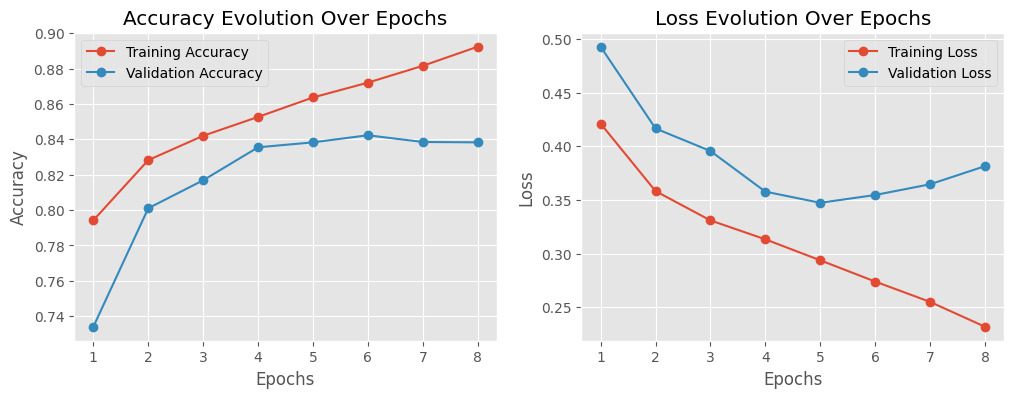

In [44]:
# Accuracy and Loss evolution throughout training

phon_backward_accuracies = {
    'Training Accuracy': phon_backward_train_metrics['accuracy'],
    'Validation Accuracy': phon_backward_valid_metrics['accuracy']
}

phon_backward_losses = {
    'Training Loss': phon_backward_train_metrics['loss'],
    'Validation Loss': phon_backward_valid_metrics['loss']
}

plot_metrics(phon_backward_accuracies, phon_backward_losses)

The most frequent label in the dataset is: m


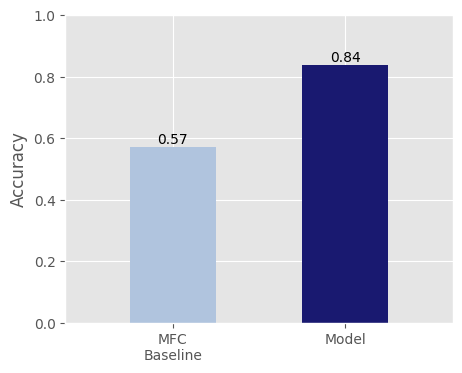

In [45]:
baseline_backward_acc = baseline_accuracy(phon_train_generator_backward, phon_valid_generator_backward, verbose=True)

compare_accuracies(baseline_backward_acc, phon_backward_valid_metrics['accuracy'][-1])

In [ ]:
phon_test_generator_backward = DataGenerator(phon_test, parentgenerator=phon_train_generator_backward, reverse_nouns=True)
phon_backward_predictions = phon_model_backward.predict(phon_test_generator_backward, hyperparameters['batch_size'], set='test')

phon_backward_predictions_df = pd.merge(
    pd.DataFrame(phon_backward_predictions), echantinom[['lemma', 'phon']], left_on='Form', right_on='phon', how='left'
    ).drop('phon', axis=1)
phon_backward_predictions_df.insert(1, 'Alt Form', phon_backward_predictions_df.pop('lemma'))
phon_backward_predictions_df.to_csv('results/phon_backward.csv', index=False)

The most frequent label in the dataset is: m


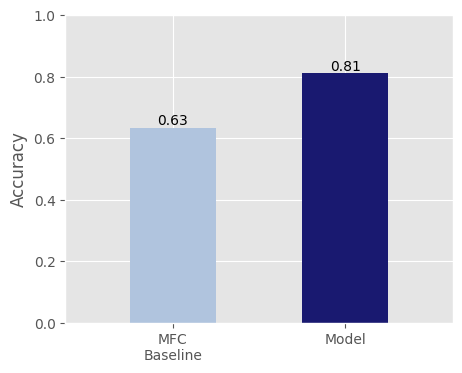

In [47]:
# Comparison with baseline on test set

phon_backward_correct = phon_backward_predictions_df[phon_backward_predictions_df['Predicted Gender'] == phon_backward_predictions_df['True Gender']]
phon_backward_acc = (phon_backward_correct.shape[0] / phon_backward_predictions_df.shape[0])

baseline_backward_acc = baseline_accuracy(phon_train_generator_backward, phon_test_generator_backward, verbose=True)

compare_accuracies(baseline_backward_acc, phon_backward_acc)

In [ ]:
statistical_check(
    phon_train, 
    phon_valid, 
    phon_test, 
    hyperparameters, 
    outfile='results/phon_backward_x10.csv', 
    runs=10, 
    reverse_nouns=True, 
    device=DEVICE
    )

'Results successfully written to results/echantinom_phon_preds_x10_backward.csv'

---
## Performance Comparison (Orthographic Reversed vs. Phonemic Reversed)

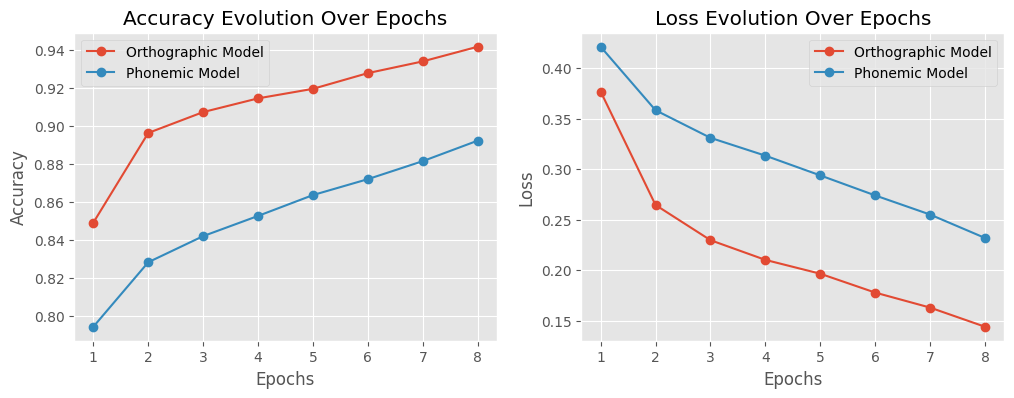

In [49]:
# Accuracy and loss of training sets

train_backward_accuracies = {
    'Orthographic Model': orth_backward_train_metrics['accuracy'],
    'Phonemic Model': phon_backward_train_metrics['accuracy']
}

train_backward_losses = {
    'Orthographic Model': orth_backward_train_metrics['loss'],
    'Phonemic Model': phon_backward_train_metrics['loss']
}

plot_metrics(train_backward_accuracies, train_backward_losses)

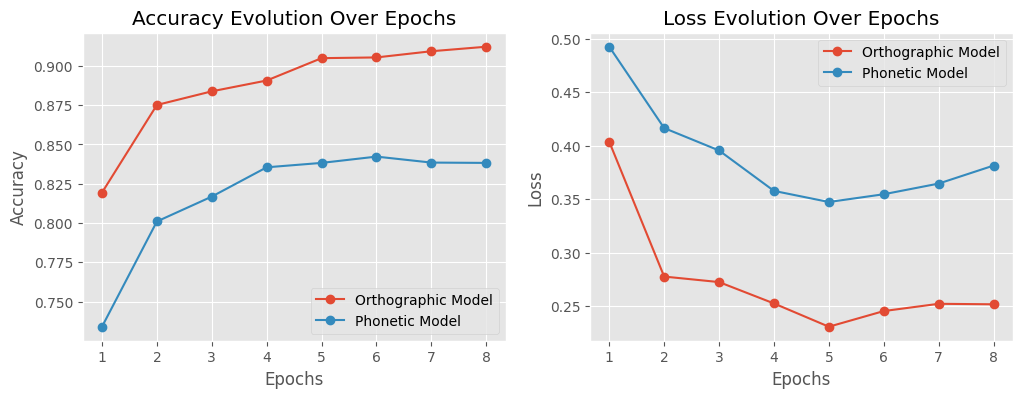

In [50]:
# Accuracy and loss of validation sets

valid_backward_accuracies = {
    'Orthographic Model': orth_backward_valid_metrics['accuracy'],
    'Phonetic Model': phon_backward_valid_metrics['accuracy']
}

valid_backward_losses = {
    'Orthographic Model': orth_backward_valid_metrics['loss'],
    'Phonetic Model': phon_backward_valid_metrics['loss']
}

plot_metrics(valid_backward_accuracies, valid_backward_losses)

---
## ☑️ Orthographic forms (Regular)

In [51]:
orth_train = pd.read_csv('data/orth_train+valid.csv')
orth_test = pd.read_csv('data/orth_test.csv')
orth_train, orth_valid = train_test_split(orth_train, test_size=0.2, random_state=42)

print("Dataset Sizes:")
print(f"Train: {len(orth_train)}")
print(f"Valid: {len(orth_valid)}")
print(f"Test: {len(orth_test)}")

Dataset Sizes:
Train: 19904
Valid: 4976
Test: 4532


In [ ]:
orth_train_generator_forward = DataGenerator(orth_train, reverse_nouns=False)
orth_valid_generator_forward = DataGenerator(orth_valid, parentgenerator=orth_train_generator_forward, reverse_nouns=False)

orth_model_forward = GenderLSTM(
    datagenerator=orth_train_generator_forward, 
    embedding_dim=hyperparameters['embed_dim'], 
    hidden_dim=hyperparameters['hidden_size'], 
    device=DEVICE, 
    reversed=False
    )

orth_forward_train_metrics, orth_forward_valid_metrics = orth_model_forward.train_model(
    traingenerator=orth_train_generator_forward,
    validgenerator=orth_valid_generator_forward,
    n_epochs=hyperparameters['n_epochs'],
    batch_size=hyperparameters['batch_size'],
    learning_rate=hyperparameters['lr'],
    verbose=True,
    save_model='models/orth_forward.pth'
    )

Epoch: 0
[Train] Loss: 0.2801   Accuracy: 88.82%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 76.31%
[Valid] Loss: 0.3211   Accuracy: 84.55%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 77.09%
----------------------------------------------------------------------------------------------------
Epoch: 1
[Train] Loss: 0.2261   Accuracy: 90.70%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 81.15%
[Valid] Loss: 0.2745   Accuracy: 87.71%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 81.64%
----------------------------------------------------------------------------------------------------
Epoch: 2
[Train] Loss: 0.2067   Accuracy: 91.55%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 82.59%
[Valid] Loss: 0.2605   Accuracy: 89.48%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 84.26%
---------------------------------------------

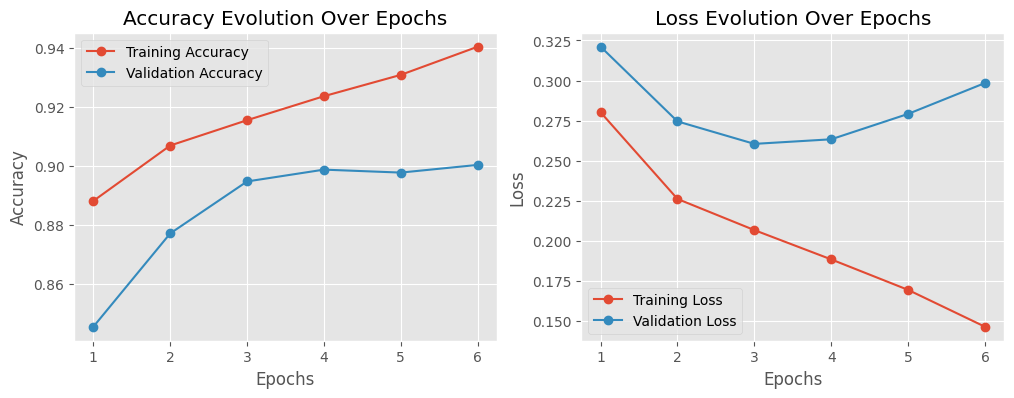

In [53]:
orth_forward_accuracies = {
    'Training Accuracy': orth_forward_train_metrics['accuracy'],
    'Validation Accuracy': orth_forward_valid_metrics['accuracy']
}

orth_forward_losses = {
    'Training Loss': orth_forward_train_metrics['loss'],
    'Validation Loss': orth_forward_valid_metrics['loss']
}

plot_metrics(orth_forward_accuracies, orth_forward_losses)

The most frequent label in the dataset is: m


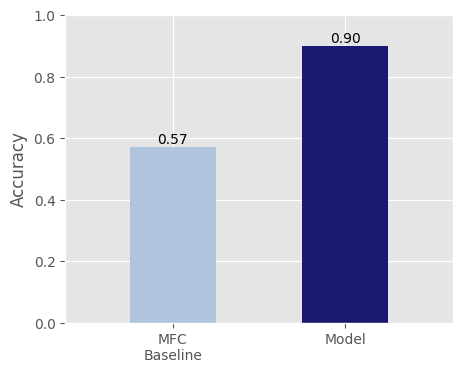

In [54]:
# Comparison with baseline on validation set

baseline_forward_acc = baseline_accuracy(orth_train_generator_forward, orth_valid_generator_forward, verbose=True)

compare_accuracies(baseline_forward_acc, orth_forward_valid_metrics['accuracy'][-1])

In [ ]:
orth_test_generator_forward = DataGenerator(orth_test, parentgenerator=orth_train_generator_forward, reverse_nouns=False)
orth_forward_predictions = orth_model_forward.predict(orth_test_generator_forward, hyperparameters['batch_size'], set='test')

orth_forward_predictions_df = pd.merge(
    pd.DataFrame(orth_forward_predictions), echantinom[['lemma', 'phon']], left_on='Form', right_on='lemma', how='left'
    ).drop('lemma', axis=1)
orth_forward_predictions_df.insert(1, 'Alt Form', orth_forward_predictions_df.pop('phon'))
orth_forward_predictions_df.to_csv('results/orth_forward.csv', index=False)

The most frequent label in the dataset is: m


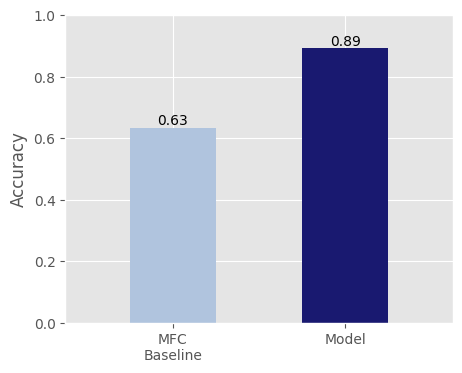

In [56]:
# Comparison with baseline on test set

orth_forward_correct = orth_forward_predictions_df[orth_forward_predictions_df['Predicted Gender'] == orth_forward_predictions_df['True Gender']]
orth_forward_acc = (orth_forward_correct.shape[0] / orth_forward_predictions_df.shape[0])

baseline_forward_acc = baseline_accuracy(orth_train_generator_forward, orth_test_generator_forward, verbose=True)

compare_accuracies(baseline_forward_acc, orth_forward_acc)

In [ ]:
statistical_check(
    orth_train, 
    orth_valid, 
    orth_test, 
    hyperparameters, 
    outfile='results/orth_forward_x10.csv', 
    runs=10, 
    reverse_nouns=False, 
    device=DEVICE
    )

'Results successfully written to results/echantinom_orth_preds_x10_forward.csv'

---
## ☑️ Phonemic forms (regular)

In [58]:
phon_train_valid = pd.read_csv('data/phon_train+valid.csv')
phon_test = pd.read_csv('data/phon_test.csv')
phon_train, phon_valid = train_test_split(phon_train_valid, test_size=0.2, random_state=42)

print("Dataset Sizes:")
print(f"Train: {len(phon_train)}")
print(f"Valid: {len(phon_valid)}")
print(f"Test: {len(phon_test)}")

Dataset Sizes:
Train: 19904
Valid: 4976
Test: 4532


In [ ]:
phon_train_generator_forward = DataGenerator(phon_train, reverse_nouns=False)
phon_valid_generator_forward = DataGenerator(phon_valid, parentgenerator=phon_train_generator_forward, reverse_nouns=False)

phon_model_forward = GenderLSTM(
    datagenerator=phon_train_generator_forward, 
    embedding_dim=hyperparameters['embed_dim'], 
    hidden_dim=hyperparameters['hidden_size'], 
    device=DEVICE, 
    reversed=True
    )

phon_forward_train_metrics, phon_forward_valid_metrics = phon_model_forward.train_model(
    traingenerator=phon_train_generator_forward,
    validgenerator=phon_valid_generator_forward,
    n_epochs=hyperparameters['n_epochs'],
    batch_size=hyperparameters['batch_size'],
    learning_rate=hyperparameters['lr'],
    verbose=True,
    save_model='models/phon_forward.pth'
    )

Epoch: 0
[Train] Loss: 0.3761   Accuracy: 82.25%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 68.75%
[Valid] Loss: 0.4295   Accuracy: 80.48%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 73.10%
----------------------------------------------------------------------------------------------------
Epoch: 1
[Train] Loss: 0.3291   Accuracy: 84.90%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 70.43%
[Valid] Loss: 0.4082   Accuracy: 81.41%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 73.25%
----------------------------------------------------------------------------------------------------
Epoch: 2
[Train] Loss: 0.3060   Accuracy: 85.95%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 71.09%
[Valid] Loss: 0.3968   Accuracy: 82.02%   Beginning of plateau (index): 0   Accuracy at the beginning of plateau: 73.93%
---------------------------------------------

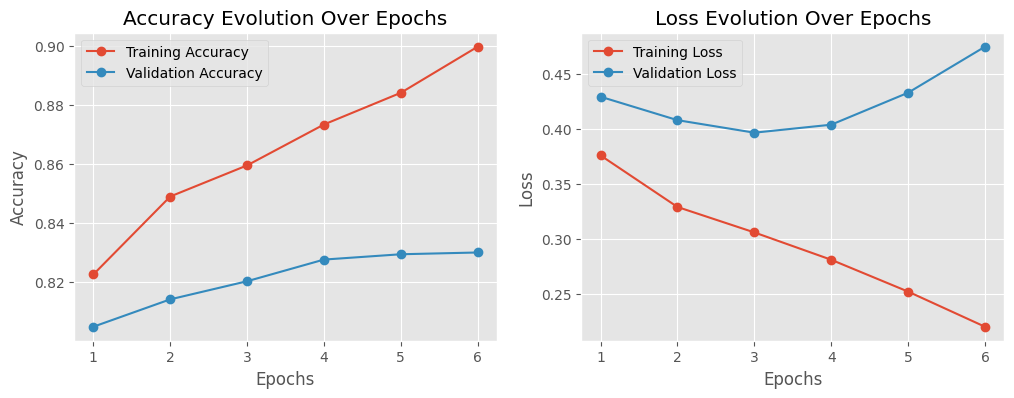

In [60]:
# Accuracy and Loss evolution throughout training

phon_forward_accuracies = {
    'Training Accuracy': phon_forward_train_metrics['accuracy'],
    'Validation Accuracy': phon_forward_valid_metrics['accuracy']
}

phon_forward_losses = {
    'Training Loss': phon_forward_train_metrics['loss'],
    'Validation Loss': phon_forward_valid_metrics['loss']
}

plot_metrics(phon_forward_accuracies, phon_forward_losses)

The most frequent label in the dataset is: m


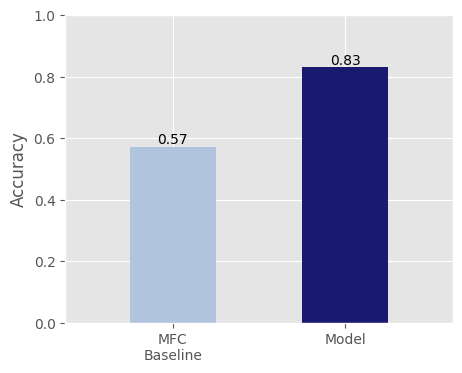

In [61]:
baseline_forward_acc = baseline_accuracy(phon_train_generator_forward, phon_valid_generator_forward, verbose=True)

compare_accuracies(baseline_forward_acc, phon_forward_valid_metrics['accuracy'][-1])

In [ ]:
phon_test_generator_forward = DataGenerator(phon_test, parentgenerator=phon_train_generator_forward, reverse_nouns=False)
phon_forward_predictions = phon_model_forward.predict(phon_test_generator_forward, hyperparameters['batch_size'], set='test')

phon_forward_predictions_df = pd.merge(
    pd.DataFrame(phon_forward_predictions), echantinom[['lemma', 'phon']], left_on='Form', right_on='phon', how='left'
    ).drop('phon', axis=1)
phon_forward_predictions_df.insert(1, 'Alt Form', phon_forward_predictions_df.pop('lemma'))
phon_forward_predictions_df.to_csv('results/phon_forward.csv', index=False)

The most frequent label in the dataset is: m


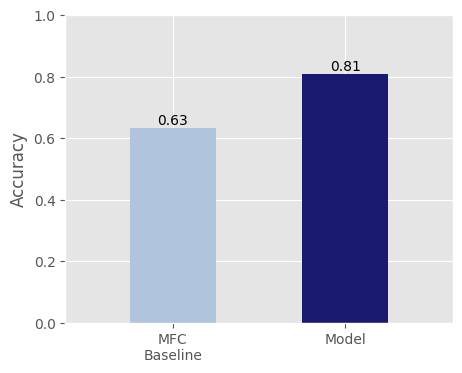

In [68]:
# Comparison with baseline on test set

phon_forward_correct = phon_forward_predictions_df[phon_forward_predictions_df['Predicted Gender'] == phon_forward_predictions_df['True Gender']]
phon_forward_acc = (phon_forward_correct.shape[0] / phon_forward_predictions_df.shape[0])

baseline_forward_acc = baseline_accuracy(phon_train_generator_forward, phon_test_generator_forward, verbose=True)

compare_accuracies(baseline_forward_acc, phon_forward_acc)

In [ ]:
statistical_check(
    phon_train, 
    phon_valid, 
    phon_test, 
    hyperparameters, 
    outfile='results/phon_forward_x10.csv', 
    runs=10, 
    reverse_nouns=False, 
    device=DEVICE
    )

'Results successfully written to results/echantinom_phon_preds_x10_forward.csv'

---
## Performance Comparison (Orthographic Regular vs. Phonemic Regular)

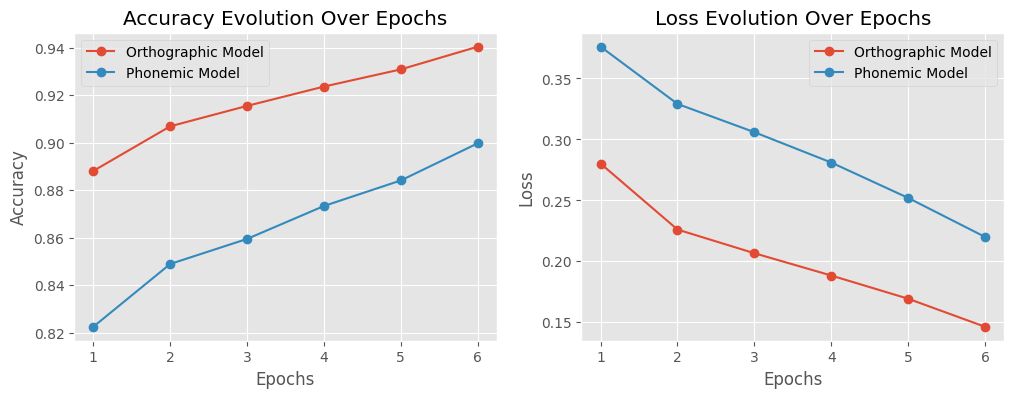

In [65]:
# Accuracy and loss of training sets

train_forward_accuracies = {
    'Orthographic Model': orth_forward_train_metrics['accuracy'],
    'Phonemic Model': phon_forward_train_metrics['accuracy']
}

train_forward_losses = {
    'Orthographic Model': orth_forward_train_metrics['loss'],
    'Phonemic Model': phon_forward_train_metrics['loss']
}

plot_metrics(train_forward_accuracies, train_forward_losses)

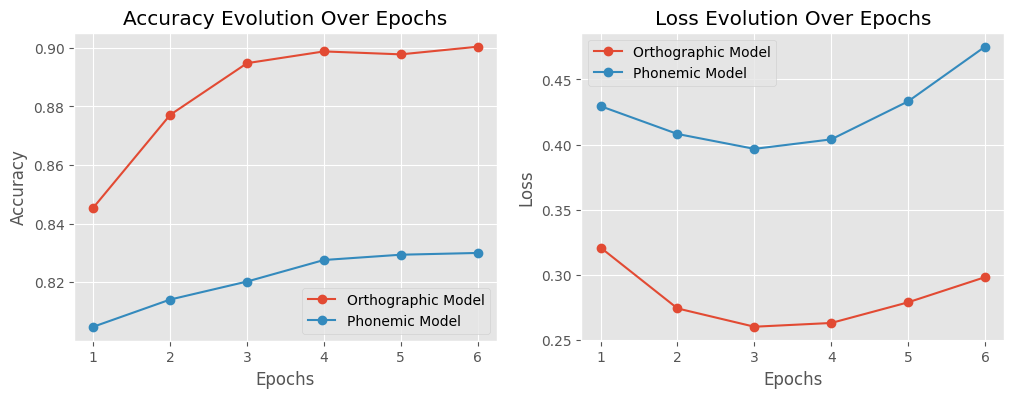

In [69]:
# Accuracy and loss of validation sets

valid_forward_accuracies = {
    'Orthographic Model': orth_forward_valid_metrics['accuracy'],
    'Phonemic Model': phon_forward_valid_metrics['accuracy']
}

valid_forward_losses = {
    'Orthographic Model': orth_forward_valid_metrics['loss'],
    'Phonemic Model': phon_forward_valid_metrics['loss']
}

plot_metrics(valid_forward_accuracies, valid_forward_losses)